In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
from tabulate import tabulate

In [2]:
data =pd.read_excel("BASE2024LIMPIA1.xlsx")
print(data.head(4))

    AÑO  MES  CONGLOME  VIVIENDA  HOGAR  CODPERSO  UBIGEO  DOMINIO  ESTRATO  \
0  2024    1     17796         1     11         2  150140        8        1   
1  2024    1     17796        48     11         1  150140        8        1   
2  2024    1     17796       111     11         1  150140        8        1   
3  2024    1     17796       136     11         1  150140        8        1   

   CODINFOR  ...  I538C1  I538D1  I538E1  I5294B  I5404B  I541A  OCU500  \
0         1  ...     NaN     NaN     NaN     NaN     NaN    NaN       1   
1         1  ...     NaN     NaN     NaN     NaN     NaN    NaN       1   
2         1  ...     NaN     NaN     NaN     NaN     NaN    NaN       1   
3         1  ...     NaN     NaN     NaN     NaN     NaN    NaN       1   

      FAC500A  NCONGLOME  SUB_CONGLOME  
0  360.413757      27216             0  
1  405.062500      27216             0  
2  242.283691      27216             0  
3  473.428162      27216             0  

[4 rows x 1425 columns

In [3]:
Q1 = data['P524A1'].quantile(0.25)
Q3 = data['P524A1'].quantile(0.75)
IQR = Q3 - Q1
filtered_data = data[(data['P524A1'] >= Q1 - 1.5 * IQR) & (data['P524A1'] <= Q3 + 1.5 * IQR)]
filtered_data['P524A1'].describe()

,P524A1
count,3001.000000
mean,1547.196601
std,1246.309755
min,13.000000
25%,500.000000
50%,1200.000000
75%,2100.000000
max,5300.000000


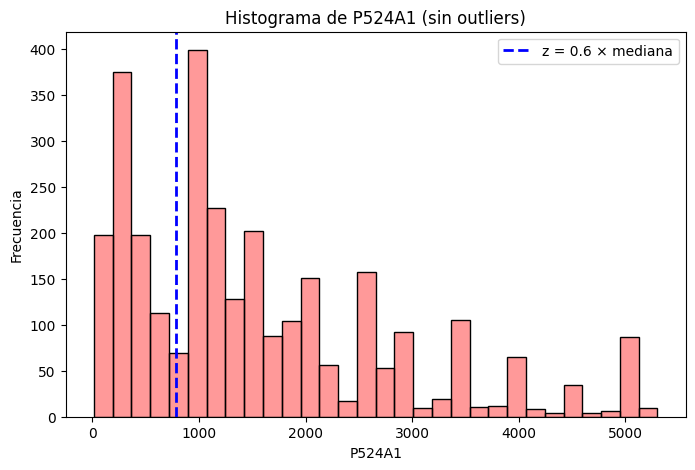

In [4]:
z = 0.6 * data['P524A1'].median()
Q1 = data['P524A1'].quantile(0.25)
Q3 = data['P524A1'].quantile(0.75)
IQR = Q3 - Q1
filtered_data = data[(data['P524A1'] >= Q1 - 1.5 * IQR) & (data['P524A1'] <= Q3 + 1.5 * IQR)]
plt.figure(figsize=(8,5))
sns.histplot(filtered_data['P524A1'], bins=30, color='red', alpha=0.4, edgecolor='black')
plt.axvline(x=z, color='blue', linestyle='--', linewidth=2, label='z = 0.6 × mediana')
plt.title('Histograma de P524A1 (sin outliers)')
plt.xlabel('P524A1')
plt.ylabel('Frecuencia')
plt.legend()

plt.show()



**UMBRAL DE POBREZA**

In [5]:
z = 0.6 * data['P524A1'].median()
print(z)

780.0


**VARIABLE POBREZA**

In [6]:
n = data.shape[0]
data['poor'] = np.where(data['P524A1'] < z, 1, 0)
print(data['poor'].value_counts())

poor
0    2385
1     897
Name: count, dtype: int64


**TAMAÑO POBLACIONAL**

In [7]:
datos_censales=pd.read_excel("DATOS CENSALES.xlsx")
print(datos_censales)

    UBIGEO      NOMBRE DEL DISTRITO  POBLACION CENSADA
0   150101                      Lima            268352
1   150102                     Ancon             62928
2   150103                       Ate            599196
3   150104                  Barranco             34378
4   150105                     Breña             85309
5   150106                Carabayllo            333045
6   150107                Chaclacayo             42912
7   150108               Chorrillos             314241
8   150109               Cieneguilla             34684
9   150110                     Comas            520450
10  150111               El Agustino            198862
11  150112            Independencia             211360
12  150113               Jesus Maria             75359
13  150114                 La Molina            140679
14  150115               La Victoria            173630
15  150116                     Lince             54711
16  150117                Los Olivos            325884
17  150118

**ESTIMACIÓN DIRECTA**

In [8]:
muestra = pd.read_excel("BASE2024LIMPIA1.xlsx")
censo = pd.read_excel("DATOS CENSALES.xlsx")
var_y = "P524A1"
var_dom = "UBIGEO"
var_w = "FAC500A"
muestra = muestra.copy()
muestra = muestra[muestra[var_y].notnull()]
muestra.loc[muestra[var_y].isin([9999, 99999, 999999]), var_y] = np.nan
muestra = muestra[muestra[var_y].between(100, 20000)]


def est_directos(x):
    if x[var_y].notnull().sum() == 0:
        return pd.Series({
            "Y_direct": np.nan,
            "SD_direct": np.nan,
            "CV_direct": np.nan,
            "n_muestra": 0
        })
    w = x[var_w]
    y = x[var_y]
    y_mean = np.average(y, weights=w)
    var_dir = np.sum((w**2) * (y - y_mean)**2) / (np.sum(w)**2)
    sd_dir = np.sqrt(var_dir)
    cv_dir = (sd_dir / y_mean) * 100
    return pd.Series({
        "Y_direct": y_mean,
        "SD_direct": sd_dir,
        "CV_direct": cv_dir,
        "n_muestra": x[var_y].notnull().sum()
    })
result = muestra.groupby(var_dom).apply(est_directos).reset_index()
result = pd.merge(censo[[var_dom, "POBLACION CENSADA"]], result, on=var_dom, how="left")
print(tabulate(result.head(42), headers="keys", tablefmt="fancy_grid", floatfmt=".2f"))


╒════╤══════════╤═════════════════════╤════════════╤═════════════╤═════════════╤═════════════╕
│    │   UBIGEO │ POBLACION CENSADA   │   Y_direct │   SD_direct │   CV_direct │   n_muestra │
╞════╪══════════╪═════════════════════╪════════════╪═════════════╪═════════════╪═════════════╡
│  0 │   150101 │ 268352              │    2219.29 │      222.20 │       10.01 │      119.00 │
├────┼──────────┼─────────────────────┼────────────┼─────────────┼─────────────┼─────────────┤
│  1 │   150102 │ 62928               │    1178.74 │      216.28 │       18.35 │       21.00 │
├────┼──────────┼─────────────────────┼────────────┼─────────────┼─────────────┼─────────────┤
│  2 │   150103 │ 599196              │    1469.17 │      107.94 │        7.35 │      224.00 │
├────┼──────────┼─────────────────────┼────────────┼─────────────┼─────────────┼─────────────┤
│  3 │   150104 │ 34378               │    2553.32 │      670.90 │       26.28 │       13.00 │
├────┼──────────┼─────────────────────┼───────────

/tmp/ipython-input-3988852058.py:32: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  result = muestra.groupby(var_dom).apply(est_directos).reset_index()


**NUMERO DE DISTRITOS EN LIMA**

In [9]:
muestra = pd.read_excel("BASE2024LIMPIA1.xlsx")
censo = pd.read_excel("DATOS CENSALES.xlsx")
muestra.columns = muestra.columns.str.strip()
censo.columns = censo.columns.str.strip()
col_distrito = [c for c in censo.columns if "NOMBRE" in c.upper() and "DISTRITO" in c.upper()][0]
conteo = muestra['UBIGEO'].value_counts().reset_index()
conteo.columns = ['UBIGEO', 'N_Muestra']
tabla = censo[['UBIGEO', col_distrito]].merge(conteo, on='UBIGEO', how='left')
tabla['N_Muestra'] = tabla['N_Muestra'].fillna(0).astype(int)

print(tabulate(tabla.head(60), headers='keys', tablefmt='fancy_grid'))


╒════╤══════════╤═════════════════════════╤═════════════╕
│    │   UBIGEO │ NOMBRE DEL DISTRITO     │   N_Muestra │
╞════╪══════════╪═════════════════════════╪═════════════╡
│  0 │   150101 │ Lima                    │         124 │
├────┼──────────┼─────────────────────────┼─────────────┤
│  1 │   150102 │ Ancon                   │          26 │
├────┼──────────┼─────────────────────────┼─────────────┤
│  2 │   150103 │ Ate                     │         233 │
├────┼──────────┼─────────────────────────┼─────────────┤
│  3 │   150104 │ Barranco                │          13 │
├────┼──────────┼─────────────────────────┼─────────────┤
│  4 │   150105 │ Breña                   │          41 │
├────┼──────────┼─────────────────────────┼─────────────┤
│  5 │   150106 │ Carabayllo              │         118 │
├────┼──────────┼─────────────────────────┼─────────────┤
│  6 │   150107 │ Chaclacayo              │          36 │
├────┼──────────┼─────────────────────────┼─────────────┤
│  7 │   15010

**MATRIZ DE LAS COVARIABLES**

In [10]:
aux = pd.read_excel("variable_auxiliares.xlsx")
print(aux.columns)

Index(['UBIGEO', 'NOMBRE_DISTRITO ', 'semana_trabajo', 'conexion_internet '], dtype='object')


In [11]:
auxiliares = pd.read_excel("variable_auxiliares.xlsx")
auxiliares = auxiliares.sort_values("UBIGEO").reset_index(drop=True)
ubigeo = auxiliares["UBIGEO"]
X_vars = auxiliares.drop(columns=["UBIGEO"]).to_numpy()
const = np.ones((X_vars.shape[0], 1))
X = np.hstack([const, X_vars])
columnas = ["const"] + list(auxiliares.columns[1:])
X_df = pd.DataFrame(X, columns=columnas)
X_df.insert(0, "UBIGEO", ubigeo)
print(tabulate(X_df.head(52), headers='keys', tablefmt='fancy_grid', floatfmt=".2f"))

╒════╤══════════╤═════════╤═════════════════════════╤══════════════════╤══════════════════════╕
│    │   UBIGEO │   const │ NOMBRE_DISTRITO         │   semana_trabajo │   conexion_internet  │
╞════╪══════════╪═════════╪═════════════════════════╪══════════════════╪══════════════════════╡
│  0 │   150101 │    1.00 │ Lima                    │             0.48 │                 0.57 │
├────┼──────────┼─────────┼─────────────────────────┼──────────────────┼──────────────────────┤
│  1 │   150102 │    1.00 │ Ancon                   │             0.44 │                 0.29 │
├────┼──────────┼─────────┼─────────────────────────┼──────────────────┼──────────────────────┤
│  2 │   150103 │    1.00 │ Ate                     │             0.47 │                 0.39 │
├────┼──────────┼─────────┼─────────────────────────┼──────────────────┼──────────────────────┤
│  3 │   150104 │    1.00 │ Barranco                │             0.54 │                 0.75 │
├────┼──────────┼─────────┼─────────────

In [12]:
X_numeric = X_df.select_dtypes(include=[np.number]).to_numpy()
ubigeo = X_df['UBIGEO'].to_numpy()


**estimacion ingreso**

In [13]:
import scipy.stats

X = np.column_stack([
    np.ones(len(aux)),
    aux['semana_trabajo'].to_numpy(),
    aux['conexion_internet '].to_numpy()
])
Y = result['Y_direct'].to_numpy()
vardir = result['SD_direct'].to_numpy()**2
mask = (~np.isnan(Y)) & (vardir > 0)
Y_valid = Y[mask]
X_valid = X[mask, :]
vardir_valid = vardir[mask]
W = np.diag(1 / vardir_valid)
XtW = X_valid.T @ W
beta_hat = np.linalg.inv(XtW @ X_valid) @ XtW @ Y_valid
cov_beta = np.linalg.inv(XtW @ X_valid)
se_beta = np.sqrt(np.diag(cov_beta))
t_values = beta_hat / se_beta
p_values = 2 * (1 - scipy.stats.norm.cdf(np.abs(t_values)))
coef_table = pd.DataFrame({
    'beta': beta_hat,
    'SE': se_beta,
    't_value': t_values,
    'p_value': p_values
}, index=['Intercepto', 'semana_trabajo', 'conexion_internet'])

print("Coeficientes del modelo Fay–Herriot:")
print(tabulate(coef_table, headers='keys', tablefmt='fancy_grid', floatfmt=".4f"))

Coeficientes del modelo Fay–Herriot:
╒═══════════════════╤════════════╤══════════╤═══════════╤═══════════╕
│                   │       beta │       SE │   t_value │   p_value │
╞═══════════════════╪════════════╪══════════╪═══════════╪═══════════╡
│ Intercepto        │  1359.6668 │ 385.1500 │    3.5302 │    0.0004 │
├───────────────────┼────────────┼──────────┼───────────┼───────────┤
│ semana_trabajo    │ -3002.1281 │ 819.2374 │   -3.6645 │    0.0002 │
├───────────────────┼────────────┼──────────┼───────────┼───────────┤
│ conexion_internet │  3783.3707 │ 192.9179 │   19.6113 │    0.0000 │
╘═══════════════════╧════════════╧══════════╧═══════════╧═══════════╛


In [14]:
import numpy as np
from scipy.optimize import minimize


Y_valid = Y[mask]
X_valid = X_numeric[mask, :]
D_valid = vardir[mask]

def reml_loglik(sigma_u2):
    sigma_u2 = sigma_u2[0] if isinstance(sigma_u2, np.ndarray) else sigma_u2
    V = D_valid + sigma_u2
    Vi = 1 / V
    XtViX = X_valid.T @ (Vi[:, None] * X_valid)
    beta_hat = np.linalg.solve(XtViX, X_valid.T @ (Vi * Y_valid))
    resid = Y_valid - X_valid @ beta_hat
    ll = 0.5 * (np.sum(np.log(V)) + np.log(np.linalg.det(XtViX)) + np.sum(resid**2 * Vi))
    return ll


res = minimize(reml_loglik, x0=[0.1], bounds=[(0, None)])
sigma_u2_hat = res.x[0]


print(f"Varianza del efecto aleatorio (σ²_u) estimada por REML: {sigma_u2_hat:.6f}")


Varianza del efecto aleatorio (σ²_u) estimada por REML: 1100350.201682


In [15]:
import numpy as np
import pandas as pd
from tabulate import tabulate
col_distrito = [c for c in censo.columns if "NOMBRE" in c.upper() and "DISTRITO" in c.upper()][0]
X_numeric = np.column_stack([
    np.ones(len(aux)),
    aux['semana_trabajo'].to_numpy(),
    aux['conexion_internet '].to_numpy()
])

Y = result['Y_direct'].to_numpy()
D_i = result['SD_direct'].to_numpy()**2
A = sigma_u2_hat
mask = (~np.isnan(Y)) & (D_i > 0)
Y_valid = Y[mask]
X_valid = X_numeric[mask, :]
D_valid = D_i[mask]

W = np.diag(1 / D_valid)
XtW = X_valid.T @ W
beta_hat = np.linalg.inv(XtW @ X_valid) @ XtW @ Y_valid
beta_hat = np.ravel(beta_hat)

print("Forma de X_numeric:", X_numeric.shape)
print("Forma de beta_hat:", beta_hat.shape)
print("Coeficientes beta_hat:", beta_hat)

Y_model = X_numeric @ beta_hat
gamma = A / (A + D_i)
gamma[np.isnan(D_i)] = 0

u_hat = (1 - gamma) * (Y - Y_model)
u_hat[np.isnan(Y)] = Y_model[np.isnan(Y)]
gamma_df = pd.DataFrame({
    'UBIGEO': result['UBIGEO'],
    'Nombre Distrito': censo[col_distrito].values,
    'Gamma': gamma,
    'u_hat': u_hat
})
print(tabulate(gamma_df.head(52), headers='keys', tablefmt='fancy_grid', floatfmt=".4f"))


Forma de X_numeric: (43, 3)
Forma de beta_hat: (3,)
Coeficientes beta_hat: [ 1359.66681769 -3002.12807538  3783.37072217]
╒════╤══════════╤═════════════════════════╤═════════╤═══════════╕
│    │   UBIGEO │ Nombre Distrito         │   Gamma │     u_hat │
╞════╪══════════╪═════════════════════════╪═════════╪═══════════╡
│  0 │   150101 │ Lima                    │  0.9571 │    6.6118 │
├────┼──────────┼─────────────────────────┼─────────┼───────────┤
│  1 │   150102 │ Ancon                   │  0.9592 │    2.1809 │
├────┼──────────┼─────────────────────────┼─────────┼───────────┤
│  2 │   150103 │ Ate                     │  0.9895 │    0.4979 │
├────┼──────────┼─────────────────────────┼─────────┼───────────┤
│  3 │   150104 │ Barranco                │  0.7097 │   -9.4564 │
├────┼──────────┼─────────────────────────┼─────────┼───────────┤
│  4 │   150105 │ Breña                   │  0.9330 │  -10.0338 │
├────┼──────────┼─────────────────────────┼─────────┼───────────┤
│  5 │   150106 │ Ca

In [16]:

censo.columns = censo.columns.str.strip()
X_df.columns = X_df.columns.str.strip()
col_distrito = [c for c in censo.columns if "NOMBRE" in c.upper() and "DISTRITO" in c.upper()][0]
X_numeric = X_df.select_dtypes(include=[np.number]).to_numpy(dtype=np.float64)
ubigeo = X_df["UBIGEO"].to_numpy()
Y = result['Y_direct'].to_numpy(dtype=np.float64)
SD = result['SD_direct'].to_numpy(dtype=np.float64)
vardir = SD**2
mask = (~np.isnan(Y)) & (vardir > 0)
Y_valid = Y[mask]
X_valid = X_numeric[mask, :]
vardir_valid = vardir[mask]
W = np.diag(1 / vardir_valid)
XtW = X_valid.T @ W
beta_hat = np.linalg.inv(XtW @ X_valid) @ XtW @ Y_valid
Y_model = X_numeric @ beta_hat
EBLUP = np.copy(Y_model)

for i in range(len(Y)):
    if not np.isnan(Y[i]):
        gamma = sigma_u2_hat / (sigma_u2_hat + vardir[i])
        EBLUP[i] = gamma * Y[i] + (1 - gamma) * Y_model[i]
    else:
        EBLUP[i] = Y_model[i]
Var_EBLUP = np.zeros_like(Y)
for i in range(len(Y)):
    if not np.isnan(Y[i]):
        gamma = sigma_u2_hat / (sigma_u2_hat + vardir[i])
        Var_EBLUP[i] = gamma**2 * vardir[i] + (1 - gamma)**2 * sigma_u2_hat
    else:
        Var_EBLUP[i] = sigma_u2_hat
SE_EBLUP = np.sqrt(Var_EBLUP)
CV_EBLUP = SE_EBLUP / np.where(np.isclose(EBLUP, 0), np.nan, EBLUP) * 100

eblup_df = pd.DataFrame({
    "UBIGEO": ubigeo,
    "EBLUP": EBLUP,
    "SE_EBLUP": SE_EBLUP,
    "CV_EBLUP": CV_EBLUP,
    "Y_direct": Y,
    "SD_direct": SD
})

distritos = censo[['UBIGEO', col_distrito]]
eblup_df = pd.merge(eblup_df, distritos, on="UBIGEO", how='left')
eblup_df = eblup_df[["UBIGEO", col_distrito, "Y_direct", "SD_direct", "EBLUP", "SE_EBLUP", "CV_EBLUP"]]

print(tabulate(eblup_df.head(52), headers='keys', tablefmt='fancy_grid', floatfmt=".2f"))

╒════╤══════════╤═════════════════════════╤════════════╤═════════════╤═════════╤════════════╤════════════╕
│    │   UBIGEO │ NOMBRE DEL DISTRITO     │   Y_direct │   SD_direct │   EBLUP │   SE_EBLUP │   CV_EBLUP │
╞════╪══════════╪═════════════════════════╪════════════╪═════════════╪═════════╪════════════╪════════════╡
│  0 │   150101 │ Lima                    │    2219.29 │      222.20 │ 2187.19 │     217.38 │       9.94 │
├────┼──────────┼─────────────────────────┼────────────┼─────────────┼─────────┼────────────┼────────────┤
│  1 │   150102 │ Ancon                   │    1178.74 │      216.28 │ 1190.69 │     211.83 │      17.79 │
├────┼──────────┼─────────────────────────┼────────────┼─────────────┼─────────┼────────────┼────────────┤
│  2 │   150103 │ Ate                     │    1469.17 │      107.94 │ 1469.20 │     107.38 │       7.31 │
├────┼──────────┼─────────────────────────┼────────────┼─────────────┼─────────┼────────────┼────────────┤
│  3 │   150104 │ Barranco           

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

In [17]:
D_i = eblup_df['SD_direct']**2
A = sigma_u2_hat
gamma = A / (A + D_i)
eblup_df['gamma'] = gamma
gamma_series = pd.Series(gamma)
summary_gamma = {
    'Min.': gamma_series.min(),
    '1st Qu.': gamma_series.quantile(0.25),
    'Median': gamma_series.median(),
    'Mean': gamma_series.mean(),
    '3rd Qu.': gamma_series.quantile(0.75),
    'Max.': gamma_series.max()
}

print("\nResumen de la variable gamma (ponderación Fay-Herriot):")
for k, v in summary_gamma.items():
    print(f"{k:8}: {v:.4f}")



Resumen de la variable gamma (ponderación Fay-Herriot):
Min.    : 0.5498
1st Qu. : 0.9146
Median  : 0.9592
Mean    : 0.9246
3rd Qu. : 0.9850
Max.    : 1.0000


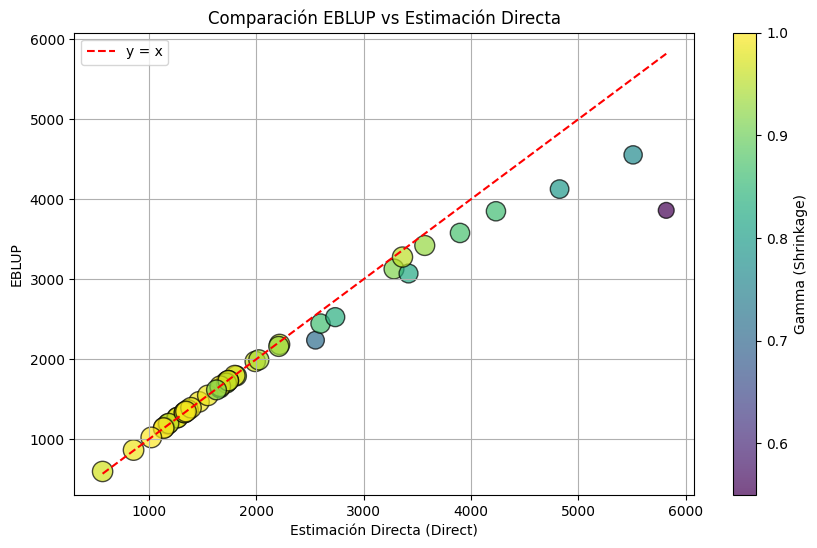

In [ ]:

D_i = eblup_df['SD_direct']**2
A = sigma_u2_hat
eblup_df['gamma'] = A / (A + D_i)
plot_df = eblup_df.dropna(subset=['Y_direct', 'EBLUP', 'gamma']).copy()
plot_df['diff'] = plot_df['EBLUP'] - plot_df['Y_direct']

plt.figure(figsize=(10,6))
scatter = plt.scatter(
    plot_df['Y_direct'],
    plot_df['EBLUP'],
    s=plot_df['gamma']*200 + 20,
    c=plot_df['gamma'],
    cmap='viridis',
    alpha=0.7,
    edgecolor='black'
)
plt.plot(
    [plot_df['Y_direct'].min(), plot_df['Y_direct'].max()],
    [plot_df['Y_direct'].min(), plot_df['Y_direct'].max()],
    color='red', linestyle='--', label='y = x'
)

plt.xlabel('Estimación Directa (Direct)')
plt.ylabel('EBLUP')
plt.title('Comparación EBLUP vs Estimación Directa')
plt.grid(True)
plt.legend()
cbar = plt.colorbar(scatter)
cbar.set_label('Gamma (Shrinkage)')
plt.show()



**INGRESOS REALES**


In [ ]:



tasa_inflacion = 0.0197


eblup_df["EBLUP_real"] = eblup_df["EBLUP"] / (1 + tasa_inflacion)
eblup_df["EBLUP_real"] = eblup_df["EBLUP_real"].round(2)


resultado = eblup_df[[col_distrito, "EBLUP", "EBLUP_real"]].copy()


resultado = resultado.sort_values(by="EBLUP_real", ascending=False)

print(f"\n✅ Tasa de inflación aplicada: {tasa_inflacion*100:.2f}%\n")
print(tabulate(resultado.head(20), headers='keys', tablefmt='fancy_grid', floatfmt=".2f"))


resultado.to_excel("EBLUP_AJUSTADO.xlsx", index=False)
print("\n📂 Archivo exportado correctamente como 'EBLUP_AJUSTADO.xlsx'")



✅ Tasa de inflación aplicada: 1.97%

╒════╤═══════════════════════╤═════════╤══════════════╕
│    │ NOMBRE DEL DISTRITO   │   EBLUP │   EBLUP_real │
╞════╪═══════════════════════╪═════════╪══════════════╡
│ 30 │ San Isidro            │ 4553.79 │      4465.81 │
├────┼───────────────────────┼─────────┼──────────────┤
│ 21 │ Miraflores            │ 4126.41 │      4046.69 │
├────┼───────────────────────┼─────────┼──────────────┤
│ 29 │ San Borja             │ 3860.82 │      3786.23 │
├────┼───────────────────────┼─────────┼──────────────┤
│ 13 │ La Molina             │ 3849.58 │      3775.21 │
├────┼───────────────────────┼─────────┼──────────────┤
│ 19 │ Magdalena del Mar     │ 3578.69 │      3509.55 │
├────┼───────────────────────┼─────────┼──────────────┤
│ 12 │ Jesus Maria           │ 3422.16 │      3356.05 │
├────┼───────────────────────┼─────────┼──────────────┤
│ 39 │ Santiago de Surco     │ 3277.83 │      3214.51 │
├────┼───────────────────────┼─────────┼──────────────┤
│ 20 │ Pue

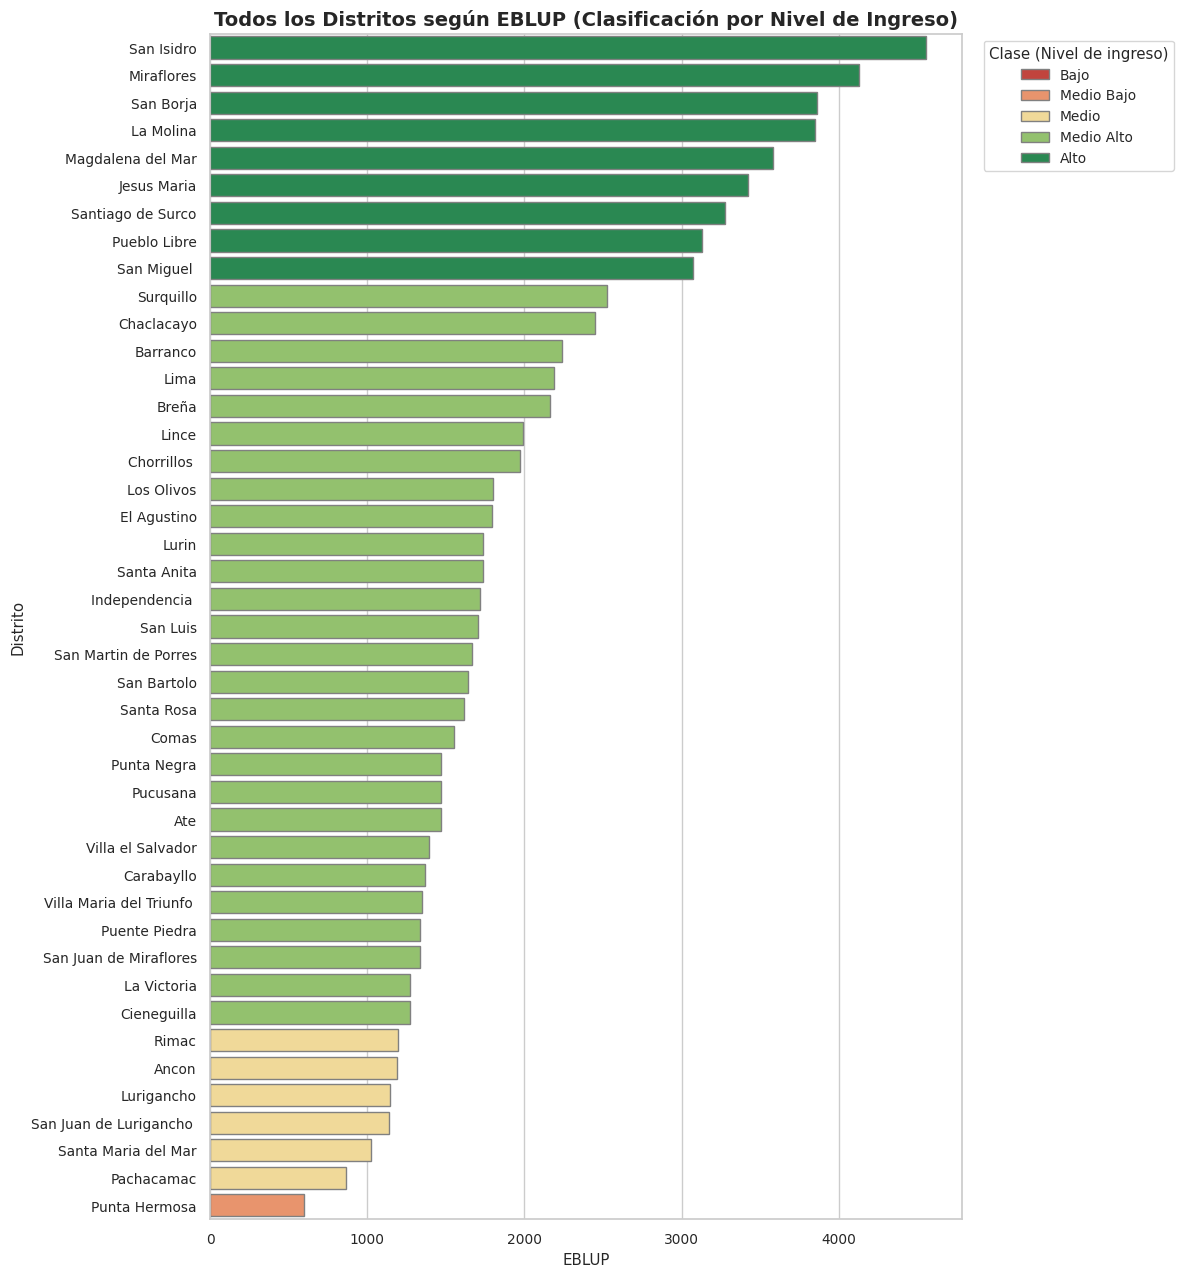

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns


bins = [0, 413, 613, 1249, 2745.6, 6805.8]
labels = ["Bajo", "Medio Bajo", "Medio", "Medio Alto", "Alto"]


eblup_df["Clase"] = pd.cut(eblup_df["EBLUP"], bins=bins, labels=labels, include_lowest=True)


resultado = eblup_df.sort_values(by="EBLUP", ascending=False)


colores = {
    "Bajo": "#d73027",
    "Medio Bajo": "#fc8d59",
    "Medio": "#fee08b",
    "Medio Alto": "#91cf60",
    "Alto": "#1a9850"
}


sns.set(style="whitegrid", font_scale=0.9)

plt.figure(figsize=(12, max(7, len(resultado) * 0.3)))
sns.barplot(
    data=resultado,
    x="EBLUP",
    y=col_distrito,
    hue="Clase",
    dodge=False,
    palette=colores,
    edgecolor="gray"
)

plt.title("Todos los Distritos según EBLUP (Clasificación por Nivel de Ingreso)", fontsize=14, weight="bold")
plt.xlabel("EBLUP")
plt.ylabel("Distrito")
plt.legend(title="Clase (Nivel de ingreso)", bbox_to_anchor=(1.02, 1), loc='upper left')
plt.tight_layout()

plt.show()


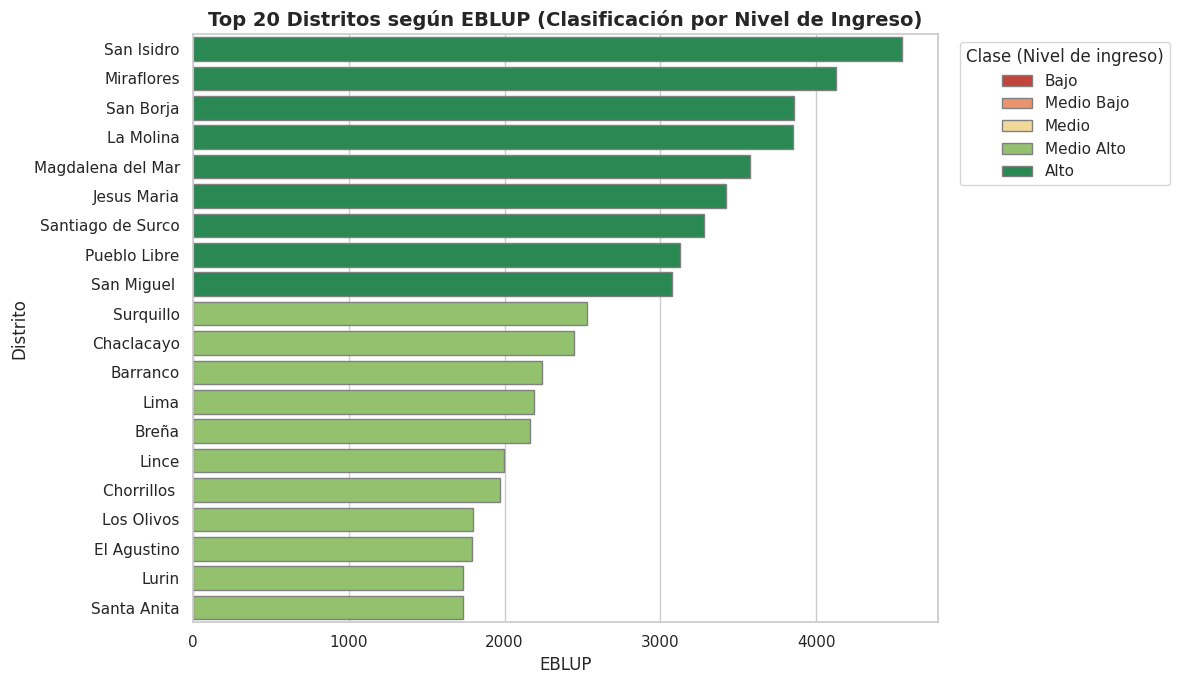

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns




bins = [0, 413, 613, 1249, 2745.6, 6805.8]
labels = ["Bajo", "Medio Bajo", "Medio", "Medio Alto", "Alto"]


eblup_df["Clase"] = pd.cut(eblup_df["EBLUP"], bins=bins, labels=labels, include_lowest=True)


resultado = eblup_df.sort_values(by="EBLUP", ascending=False)


resultado_top = resultado.head(20)


colores = {
    "Bajo": "#d73027",
    "Medio Bajo": "#fc8d59",
    "Medio": "#fee08b",
    "Medio Alto": "#91cf60",
    "Alto": "#1a9850"
}


sns.set(style="whitegrid", font_scale=1.0)

plt.figure(figsize=(12, 7))
sns.barplot(
    data=resultado_top,
    x="EBLUP",
    y=col_distrito,
    hue="Clase",
    dodge=False,
    palette=colores,
    edgecolor="gray"
)

plt.title("Top 20 Distritos según EBLUP (Clasificación por Nivel de Ingreso)", fontsize=14, weight="bold")
plt.xlabel("EBLUP")
plt.ylabel("Distrito")
plt.legend(title="Clase (Nivel de ingreso)", bbox_to_anchor=(1.02, 1), loc='upper left')
plt.tight_layout()

plt.show()


In [ ]:
import pandas as pd
import numpy as np

# === Ruta del archivo ===
file_path = "INGRESOS REALES 2019-2024.xlsx"

# === Cargar todas las hojas ===
excel_file = pd.ExcelFile(file_path)
print("Hojas detectadas:", excel_file.sheet_names)

# === Función para detectar encabezado dinámico ===
def limpiar_hoja(nombre_hoja):
    df_raw = pd.read_excel(file_path, sheet_name=nombre_hoja, header=None)

    # Buscar la fila donde aparece 'EBLUP_REAL'
    fila_encabezado = None
    for i, fila in df_raw.iterrows():
        if fila.astype(str).str.contains("EBLUP_REAL", case=False, na=False).any():
            fila_encabezado = i
            break

    if fila_encabezado is None:
        print(f"⚠️ No se encontró encabezado en la hoja {nombre_hoja}")
        return pd.DataFrame()

    # Redefinir encabezado desde esa fila
    df = pd.read_excel(file_path, sheet_name=nombre_hoja, header=fila_encabezado)

    # Normalizar nombres de columnas
    df.columns = df.columns.str.strip().str.upper()

    # Seleccionar solo las columnas de interés
    posibles_nombres = ["NOMBRE_DEL_DISTRITO", "DISTRITO", "NOMBRE", "NOMBRE DISTRITO"]
    col_distrito = next((c for c in df.columns if any(p in c for p in posibles_nombres)), None)
    col_valor = next((c for c in df.columns if "EBLUP_REAL" in c.upper()), None)

    if col_distrito is None or col_valor is None:
        print(f"⚠️ No se encontraron columnas esperadas en {nombre_hoja}")
        return pd.DataFrame()

    df = df[[col_distrito, col_valor]].copy()
    df.columns = ["NOMBRE_DEL_DISTRITO", "EBLUP_REAL"]

    # Convertir a numérico
    df["EBLUP_REAL"] = pd.to_numeric(df["EBLUP_REAL"], errors="coerce")

    # Agregar columna de año
    df["AÑO"] = nombre_hoja

    # Limpiar nombres de distritos
    df["NOMBRE_DEL_DISTRITO"] = (
        df["NOMBRE_DEL_DISTRITO"]
        .astype(str)
        .str.strip()
        .str.replace(r"\s+", " ", regex=True)
        .str.title()
    )

    return df.dropna(subset=["NOMBRE_DEL_DISTRITO"])

# === Leer todas las hojas y unirlas ===
todas = []
for hoja in excel_file.sheet_names:
    df = limpiar_hoja(hoja)
    if not df.empty:
        todas.append(df)

# Unir en una sola tabla
tabla_long = pd.concat(todas, ignore_index=True)
print("\n✅ Datos combinados correctamente:", tabla_long.shape)
display(tabla_long.head())

# === Pivotear la tabla: distritos como filas, años como columnas ===
tabla = tabla_long.pivot(index="NOMBRE_DEL_DISTRITO", columns="AÑO", values="EBLUP_REAL")
tabla = tabla.sort_index(axis=1)
tabla.reset_index(inplace=True)

print("\n✅ Tabla consolidada (vista previa):")
display(tabla.head())


Hojas detectadas: ['2024', '2023', '2022', '2021', '2020', '2019']

✅ Datos combinados correctamente: (258, 3)


,NOMBRE_DEL_DISTRITO,EBLUP_REAL,AÑO
0,Santiago De Surco,2780.96,2024
1,Jesus Maria,2712.49,2024
2,La Molina,2610.15,2024
3,San Isidro,2561.67,2024
4,Magdalena Del Mar,2504.39,2024



✅ Tabla consolidada (vista previa):


AÑO,NOMBRE_DEL_DISTRITO,2019,2020,2021,2022,2023,2024
0,Ancon,894.00,747.49,603.33,871.09,1282.14,1230.22
1,Ate,1137.47,1126.68,1161.65,1147.36,1238.11,1440.99
2,Barranco,1295.72,1708.09,1155.13,1353.74,1860.54,1687.01
3,Breña,1427.42,1560.56,1579.13,1805.24,2054.70,1899.80
4,Carabayllo,845.35,1031.95,975.83,1087.60,1466.28,1346.98


Top 5 distritos con mayor decrecimiento acumulado 2019–2024:


AÑO,NOMBRE_DEL_DISTRITO,CREC_ACUM
25,Punta Hermosa,-53.90
29,San Borja,-39.55
20,Miraflores,-34.15
30,San Isidro,-29.02
40,Surquillo,-17.35


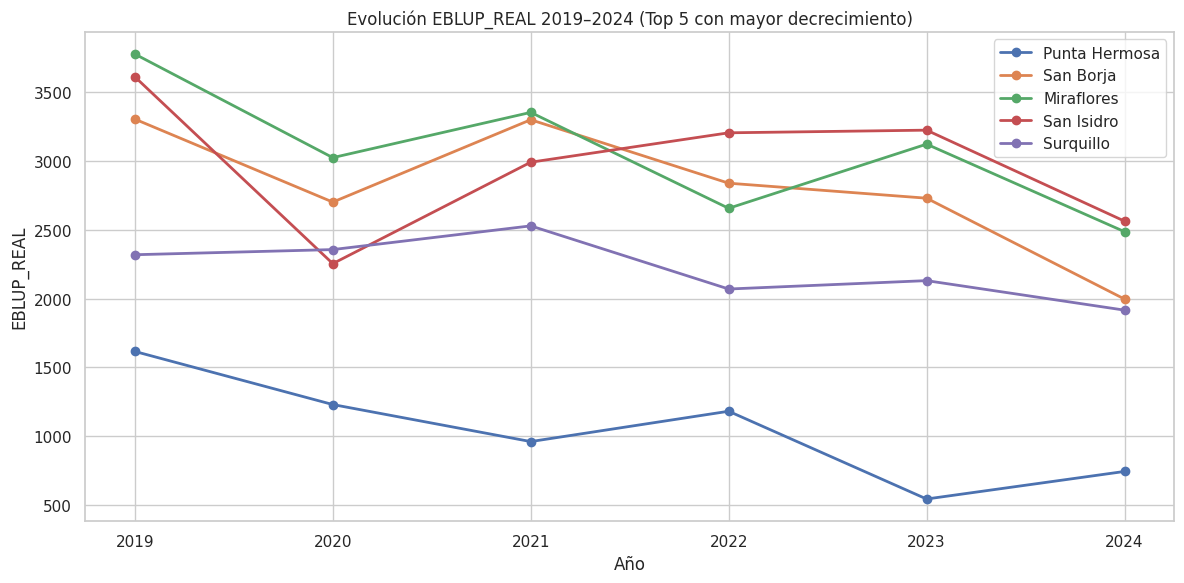

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt

# --- Asegurar columnas de años ---
años = ["2019","2020","2021","2022","2023","2024"]
for a in años:
    df_f[a] = pd.to_numeric(df_f[a], errors="coerce")

# --- Excluir Pucusana ---
df_f = df_f[df_f["NOMBRE_DEL_DISTRITO"].str.upper() != "PUCUSANA"].copy()

# --- Calcular crecimiento acumulado respecto a 2019 ---
df_f["CREC_ACUM"] = ((df_f["2024"] - df_f["2019"]) / df_f["2019"]) * 100

# --- Seleccionar top 5 distritos con mayor DECRECIMIENTO ---
top5_decr = df_f.sort_values("CREC_ACUM", ascending=True).head(5)

print("Top 5 distritos con mayor decrecimiento acumulado 2019–2024:")
display(top5_decr[["NOMBRE_DEL_DISTRITO", "CREC_ACUM"]].round(2))

# --- Graficar evolución año por año ---
plt.figure(figsize=(12,6))

for _, fila in top5_decr.iterrows():
    plt.plot(
        años,
        fila[años],
        marker="o",
        linewidth=2,
        label=fila["NOMBRE_DEL_DISTRITO"]
    )

plt.xlabel("Año")
plt.ylabel("EBLUP_REAL")
plt.title("Evolución EBLUP_REAL 2019–2024 (Top 5 con mayor decrecimiento)")
plt.grid(True)
plt.legend()
plt.tight_layout()
plt.show()


In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
from scipy.stats import pearsonr

# --- Asegurar columnas de años ---
años = ["2019","2020","2021","2022","2023","2024"]
for a in años:
    df_f[a] = pd.to_numeric(df_f[a], errors="coerce")

# --- Excluir Pucusana ---
df_f = df_f[df_f["NOMBRE_DEL_DISTRITO"].str.upper() != "PUCUSANA"].copy()

# --- Calcular crecimiento acumulado respecto a 2019 ---
df_f["CREC_ACUM"] = ((df_f["2024"] - df_f["2019"]) / df_f["2019"]) * 100

# --- Seleccionar top 5 distritos con mayor DECRECIMIENTO ---
top5_decr = df_f.sort_values("CREC_ACUM", ascending=True).head(5)

print("Top 5 distritos con mayor decrecimiento acumulado 2019–2024:")
display(top5_decr[["NOMBRE_DEL_DISTRITO", "CREC_ACUM"]].round(2))

# ================================================================
# ========== CÁLCULO DE CORRELACIÓN PEARSON + P-VALUE ============
# ================================================================

# Variables auxiliares numéricas
aux_cols = [c for c in df_f.columns if c not in años + ["NOMBRE_DEL_DISTRITO", "CREC_ACUM"]]

resultado = []
for col in aux_cols:
    # evitar errores si hay columnas no numéricas
    try:
        r, p = pearsonr(df_f[col].astype(float), df_f["P254A1"].astype(float))
        resultado.append([col, r, p])
    except:
        pass

tabla_corr = pd.DataFrame(resultado, columns=["variable", "pearson", "p_value"])

print("\nCorrelaciones con P254A1:")
display(tabla_corr)

# ================================================================
# ================ GRÁFICA CON LÍNEA ROJA =========================
# ================================================================

# Tomamos la primera variable auxiliar solo como ejemplo
if len(tabla_corr) > 0:
    v = tabla_corr.iloc[0]["variable"]

    plt.figure(figsize=(8,5))
    plt.scatter(df_f[v], df_f["P254A1"], alpha=0.5)
    # línea de regresión (línea rojita)
    m, b = np.polyfit(df_f[v], df_f["P254A1"], 1)
    plt.plot(df_f[v], m*df_f[v] + b, color="red")

    plt.xlabel(v)
    plt.ylabel("P254A1")
    plt.title(f"Correlación entre {v} y P254A1")
    plt.grid(True)
    plt.show()


Top 5 distritos con mayor decrecimiento acumulado 2019–2024:


AÑO,NOMBRE_DEL_DISTRITO,CREC_ACUM
25,Punta Hermosa,-53.90
29,San Borja,-39.55
20,Miraflores,-34.15
30,San Isidro,-29.02
40,Surquillo,-17.35



Correlaciones con P254A1:


,variable,pearson,p_value


Top 5 distritos con mayor crecimiento acumulado 2019–2024 (excluyendo Pucusana):


AÑO,NOMBRE_DEL_DISTRITO,CREC_ACUM
5,Chaclacayo,87.08
28,San Bartolo,63.08
4,Carabayllo,59.34
26,Punta Negra,54.12
10,Independencia,49.89


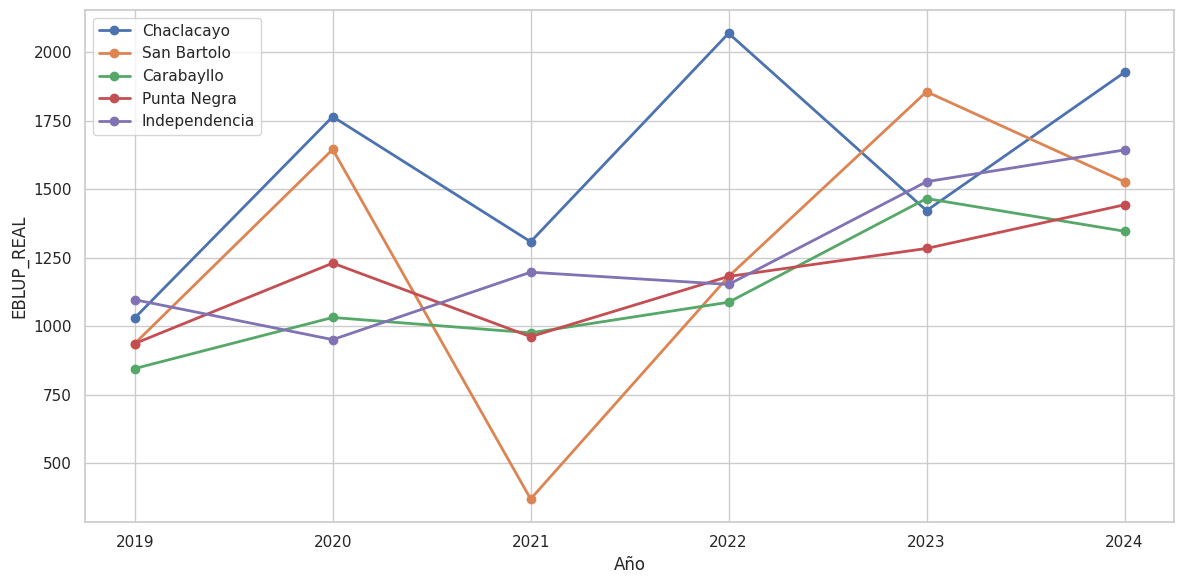

In [ ]:
import matplotlib.pyplot as plt
import pandas as pd

# --- Copiar la tabla pivotada ---
df_f = tabla.copy()

# --- Columnas de años ---
años = ["2019","2020","2021","2022","2023","2024"]
for a in años:
    df_f[a] = pd.to_numeric(df_f[a], errors="coerce")

# --- Excluir Pucusana ---
df_f = df_f[df_f["NOMBRE_DEL_DISTRITO"].str.upper() != "PUCUSANA"].copy()

# --- Calcular crecimiento acumulado 2019–2024 ---
df_f["CREC_ACUM"] = ((df_f["2024"] - df_f["2019"]) / df_f["2019"]) * 100

# --- Seleccionar top 5 distritos con mayor crecimiento ---
top5_crec = df_f.sort_values("CREC_ACUM", ascending=False).head(5)

print("Top 5 distritos con mayor crecimiento acumulado 2019–2024 (excluyendo Pucusana):")
display(top5_crec[["NOMBRE_DEL_DISTRITO", "CREC_ACUM"]].round(2))

# --- Graficar evolución año por año ---
plt.figure(figsize=(12,6))

for _, fila in top5_crec.iterrows():
    plt.plot(años, fila[años], marker="o", linewidth=2, label=fila["NOMBRE_DEL_DISTRITO"])

plt.xlabel("Año")
plt.ylabel("EBLUP_REAL")
plt.grid(True)
plt.legend()
plt.tight_layout()
plt.show()


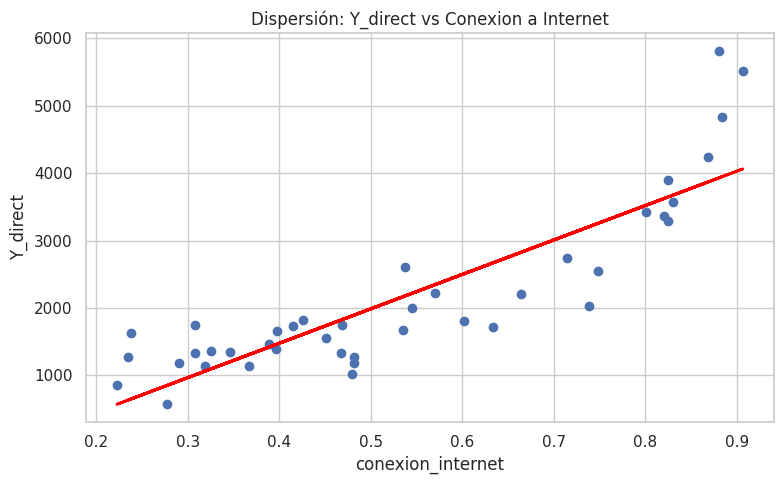

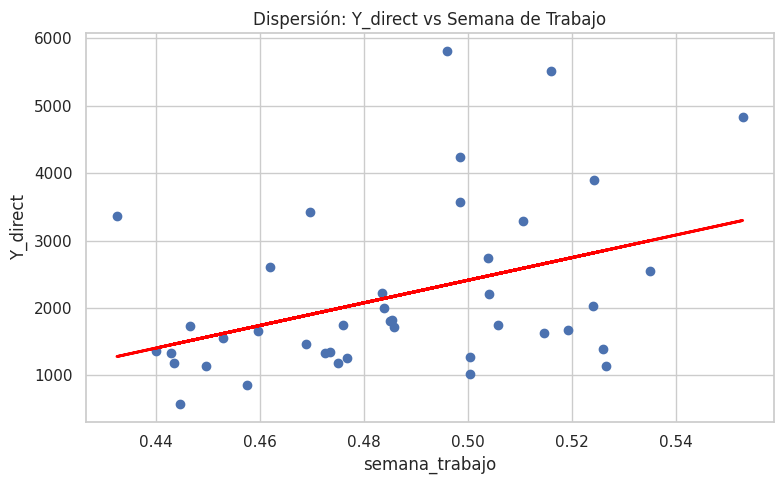

In [ ]:
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np

# --- 1. Unir los datos ---
base = pd.merge(
    result[["UBIGEO", "Y_direct"]],
    X_df[["UBIGEO", "conexion_internet", "semana_trabajo"]],
    on="UBIGEO",
    how="inner"
)

# --- 2. Convertir a números ---
for col in ["conexion_internet", "semana_trabajo", "Y_direct"]:
    base[col] = pd.to_numeric(base[col], errors="coerce")

base = base.dropna(subset=["Y_direct", "conexion_internet", "semana_trabajo"])


# =================================================================================
# 1) DISPERSIÓN: Y_direct vs conexion_internet CON LÍNEA ROJA
# =================================================================================
x = base["conexion_internet"]
y = base["Y_direct"]

# Ajustar línea de regresión
coef = np.polyfit(x, y, 1)
poly1d_fn = np.poly1d(coef)

plt.figure(figsize=(8, 5))
plt.scatter(x, y)
plt.plot(x, poly1d_fn(x), color="red", linewidth=2)   # línea rojita
plt.xlabel("conexion_internet")
plt.ylabel("Y_direct")
plt.title("Dispersión: Y_direct vs Conexion a Internet")
plt.grid(True)
plt.tight_layout()
plt.show()


# =================================================================================
# 2) DISPERSIÓN: Y_direct vs semana_trabajo CON LÍNEA ROJA
# =================================================================================
x = base["semana_trabajo"]
y = base["Y_direct"]

coef = np.polyfit(x, y, 1)
poly1d_fn = np.poly1d(coef)

plt.figure(figsize=(8, 5))
plt.scatter(x, y)
plt.plot(x, poly1d_fn(x), color="red", linewidth=2)   # línea rojita
plt.xlabel("semana_trabajo")
plt.ylabel("Y_direct")
plt.title("Dispersión: Y_direct vs Semana de Trabajo")
plt.grid(True)
plt.tight_layout()
plt.show()


In [ ]:
from scipy.stats import pearsonr
import pandas as pd
import numpy as np

# --- Unir los datos ---
base = pd.merge(
    result[["UBIGEO", "Y_direct"]],
    X_df[["UBIGEO", "conexion_internet", "semana_trabajo"]],
    on="UBIGEO",
    how="inner"
)

# Asegurar que todo sea numérico
for col in ["conexion_internet", "semana_trabajo", "Y_direct"]:
    base[col] = pd.to_numeric(base[col], errors="coerce")

# Quitar NA
base = base.dropna(subset=["Y_direct", "conexion_internet", "semana_trabajo"])

# Lista de variables auxiliares
aux_vars = ["conexion_internet", "semana_trabajo"]

# Crear tabla
rows = []
for var in aux_vars:
    r, p = pearsonr(base[var], base["Y_direct"])
    rows.append([var, r, p])

tabla_corr = pd.DataFrame(rows, columns=["variable", "pearson", "p_value"])
print(tabla_corr)


            variable   pearson       p_value
0  conexion_internet  0.867933  2.035900e-13
1     semana_trabajo  0.400659  9.434573e-03
